In [1]:
##############
## INITIATE ##
##############

## Imports
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

## Import modules
from f_dataset_augmented import ImageDataset
from f_dataset_filtered import FilteredImageDataset

#
###

In [4]:
###########################
## SCRIPT CONFIGURATIONS ##
###########################

## Set device
device = 'mps'

## Define paths and parameters
# dataset_path = '/Users/user/Documents/projects/GlandSeg/data/examples/in_tmp'
dataset_path = '/Users/user/Documents/projects/GlandSeg/outputs/V2_0_0_20250120/o1_extracted_glands/tcga_ffpes_V1'
batch_size = 1
val_split = 0.2
test_split = 0.1

#
###

In [3]:
#######################
## LOAD SINGLE MODEL ##
#######################

## Load filter model
from f_model_unet import UNet
pt_filter_model_weights = 'models/model_unet_V1_1.pth'
model = UNet(n_classes=3).to(device)
model.load_state_dict(torch.load(pt_filter_model_weights, map_location=device)) # Load weights      

#
###

/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_7961/1148358238.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pt_filter_mod

<All keys matched successfully>

In [4]:
#######################
## LOAD SINGLE MODEL ##
#######################

## Load filter model
from f_model_transunet import UNetTransformer
pt_filter_model_weights = 'models/model_transunet_V1_1.pth'
model = UNetTransformer(n_classes=3).to(device)
model.load_state_dict(torch.load(pt_filter_model_weights, map_location=device)) # Load weights  

#
###

/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_7961/3274145956.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pt_filter_mod

<All keys matched successfully>

In [5]:
#####################
## LOAD DUAL MODEL ##
#####################

## Load filter model
from f_model_unet import UNet
pt_filter_model_weights = 'models/model_unet_V1_1.pth'
model_1 = UNet(n_classes=3).to(device)
model_1.load_state_dict(torch.load(pt_filter_model_weights, map_location=device)) # Load weights      

## Load filter model
from f_model_transunet import UNetTransformer
pt_filter_model_weights = 'models/model_transunet_V1_1.pth'
model_2 = UNetTransformer(n_classes=3).to(device)
model_2.load_state_dict(torch.load(pt_filter_model_weights, map_location=device)) # Load weights      

## Combine models
def model(X):
    return model_1(X) + model_2(X)

#
###

/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_7961/192641973.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load(pt_filter_mo

In [5]:
#########################
## LOAD AND SPLIT DATA ##
#########################

## Load dataset
dataset = ImageDataset(folder_path=dataset_path, augment=False, resize=1024)

## Split dataset into train, validation, and test
train_size = int((1 - val_split - test_split) * len(dataset))
val_size = int(val_split * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

## Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#
###

In [7]:
####################
## VISUALISE DATA ##
####################

## Local function
def mps_to_numpy(X):
    images = []
    for x in X:
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)        
        x = (x * 255).astype('uint8')        
        images += [x]        
    return images

## Transformations
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.4, saturation=0.4, hue=0.4)
    ])

## Select dataloader
dataloader = train_loader

## Example of iterating through the DataLoader
images = []
# filters = []
# embeddings = []
k = 0
with torch.no_grad():
    for X, _ in dataloader:

        ## Inputs
        X = X.to(device)

        ## Transform
        # X = transform(X)
        # X = torch.sigmoid(X)

        ## Filter
        # filter_ = torch.sigmoid(model(X)) # torch.sigmoid(model_1(X)) > 0.5 # Filter

        ## Embeddings
        # embeddings_ = model.encode(X) # torch.sigmoid(model_1(X)) > 0.5 # Filter        
        # embeddings_ = torch.sigmoid(embeddings_)

        ## Collect
        images += [mps_to_numpy(X)[0]]
        # filters += [mps_to_numpy(filter_)[0]]
        # embeddings += [mps_to_numpy(embeddings_)[0]]

        ## Iterator
        k += 1
        if k > 16:
            break

#
###

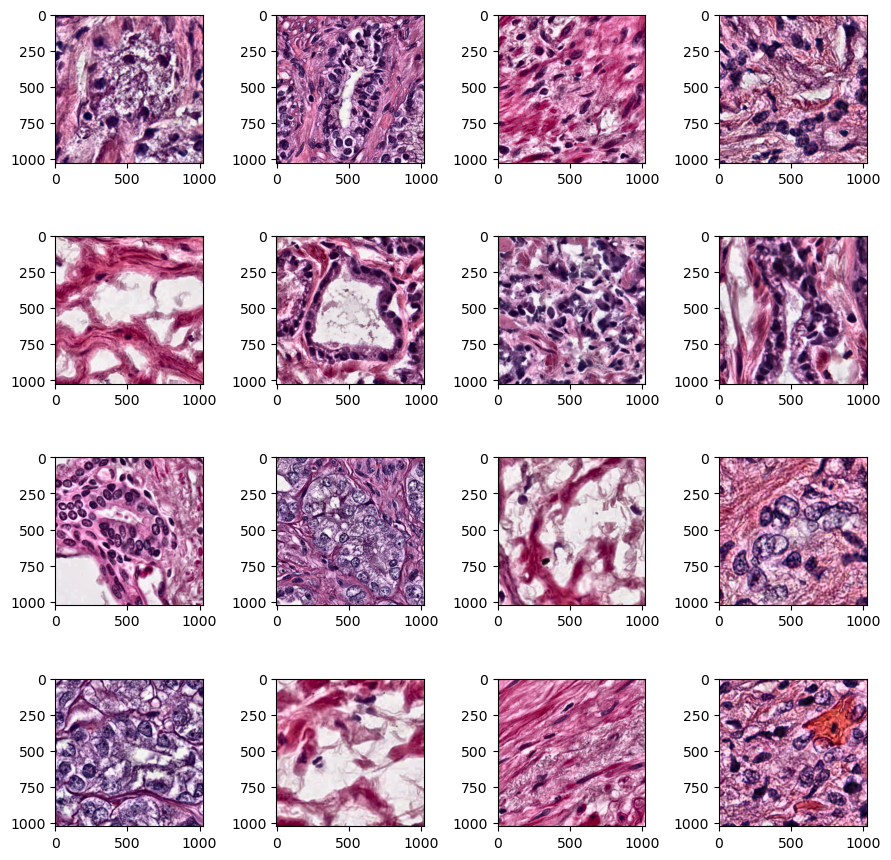

'\n## Visualise image\nfig, axes = plt.subplots(4, 4, figsize=(9,9))\nk = 0\nfor i in range(4):\n    for j in range(4):\n        axis = axes[i,j]        \n        axis.imshow(filters[k])\n        k += 1\nplt.tight_layout()\nplt.show()\nplt.close()\n\n## Visualise image\nfig, axes = plt.subplots(4, 4, figsize=(9,9))\nk = 0\nfor i in range(4):\n    for j in range(4):\n        axis = axes[i,j]        \n        axis.imshow(embeddings[k].mean(2))\n        k += 1\nplt.tight_layout()\nplt.show()\nplt.close()\n'

In [8]:
###########################
## VISUALISE PREDICTIONS ##
###########################

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(9,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(images[k])
        k += 1
plt.tight_layout()
plt.show()
plt.close()

"""
## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(9,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(filters[k])
        k += 1
plt.tight_layout()
plt.show()
plt.close()

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(9,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(embeddings[k].mean(2))
        k += 1
plt.tight_layout()
plt.show()
plt.close()
"""

#
###

In [7]:
#########################
## LOAD AND SPLIT DATA ##
#########################

## Load dataset
dataset = FilteredImageDataset(folder_path=dataset_path, augment=False)
# dataset.filter_model = model

## Split dataset into train, validation, and test
train_size = int((1 - val_split - test_split) * len(dataset))
val_size = int(val_split * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

## Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#
###

/Users/user/Documents/GitHub/GlandSeg/scripts/GlandPhenotyper-V1/scripts/segmentedInputs-V0_0_0/f_dataset_filtered.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stat

In [8]:
####################
## VISUALISE DATA ##
####################

## Local function
def mps_to_numpy(X):
    images = []
    for x in X:
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)        
        x = (x * 255).astype('uint8')        
        images += [x]
    return images

## Transformations
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.4, saturation=0.4, hue=0.4)
    ])

## Select dataloader
dataloader = train_loader

## Example of iterating through the DataLoader
images = []
# filters = []
k = 0
with torch.no_grad():
    for X, _ in dataloader:

        print(_)
        
        ## Inputs
        X = X.to(device)

        ## Transform
        # X = transform(X)
        X = torch.sigmoid(X)

        ## Filter
        # filter_ = torch.sigmoid(model(X)) # torch.sigmoid(model_1(X)) > 0.5 # Filter        

        ## Collect
        images += [mps_to_numpy(X)[0]]
        # filters += [mps_to_numpy(filter_)[0]]

        ## Iterator
        k += 1
        if k > 16:
            break

#
###

NotImplementedError: The operator 'aten::_upsample_bilinear2d_aa.out' is not currently implemented for the MPS device. If you want this op to be added in priority during the prototype phase of this feature, please comment on https://github.com/pytorch/pytorch/issues/77764. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.

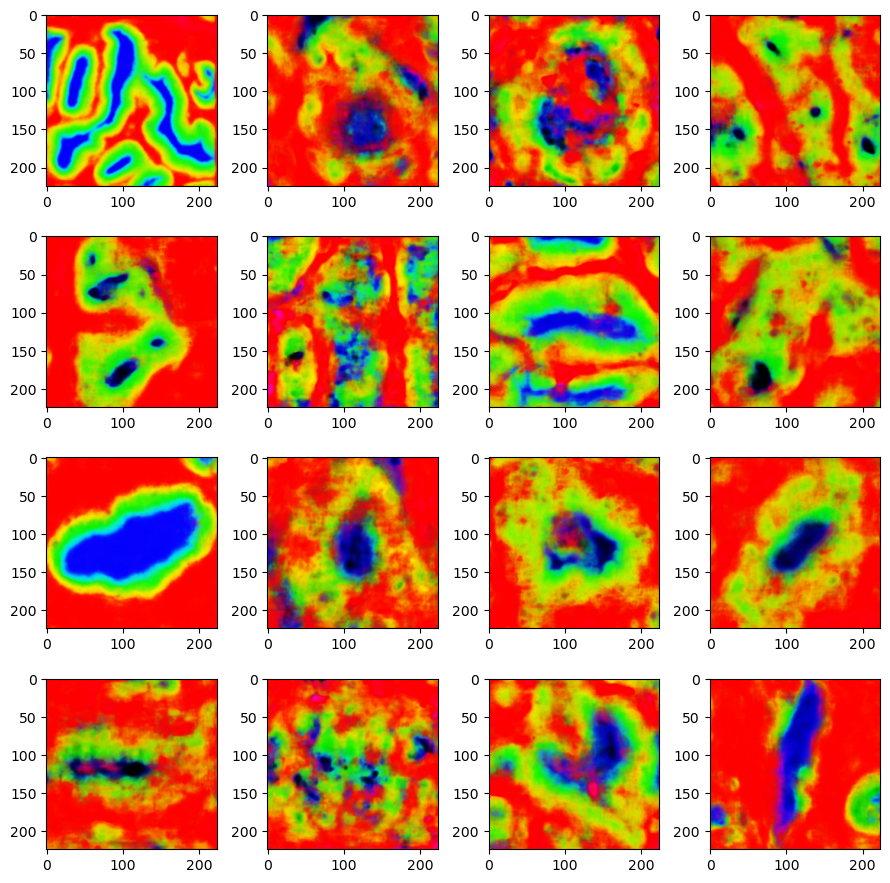

In [13]:
###########################
## VISUALISE PREDICTIONS ##
###########################

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(9,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(images[k])
        k += 1
plt.tight_layout()
plt.show()
plt.close()

#
###